In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.RandomPerspective(
        distortion_scale=0.2,
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [3]:
full_dataset = datasets.ImageFolder(
    "dataset",
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.efficientnet_b0(
    weights='IMAGENET1K_V1'
)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 2)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\TVM2/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:03<00:00, 6.40MB/s]


In [8]:
for param in model.features.parameters():
    param.requires_grad = False

In [9]:
class_weights = torch.tensor([
    1.0,
    206/116
]).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad,
           model.parameters()),
    lr=1e-3
)

In [ ]:
from sklearn.metrics import accuracy_score

num_epochs = 5

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()

    preds = []
    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.numpy())

    acc = accuracy_score(true, preds)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {acc*100:.2f}%")
    print("-"*40)

Epoch 1/5
Train Loss: 0.6547
Validation Accuracy: 87.69%
----------------------------------------
Epoch 2/5
Train Loss: 0.4425
Validation Accuracy: 81.54%
----------------------------------------
Epoch 3/5
Train Loss: 0.4229
Validation Accuracy: 81.54%
----------------------------------------
Epoch 4/5
Train Loss: 0.3992
Validation Accuracy: 81.54%
----------------------------------------
Epoch 5/5
Train Loss: 0.3803
Validation Accuracy: 84.62%
----------------------------------------


In [ ]:
for param in model.features.parameters():
    param.requires_grad = True
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)

In [ ]:
num_epochs = 15

best_acc = 0

for epoch in range(num_epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()

    preds = []
    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.numpy())

    acc = accuracy_score(true, preds)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),
                   "best_efficientnet.pth")

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {acc*100:.2f}%")
    print(f"Best Accuracy: {best_acc*100:.2f}%")
    print("-"*40)

Epoch 1/15
Train Loss: 0.3007
Validation Accuracy: 83.08%
Best Accuracy: 83.08%
----------------------------------------
Epoch 2/15
Train Loss: 0.2914
Validation Accuracy: 86.15%
Best Accuracy: 86.15%
----------------------------------------
Epoch 3/15
Train Loss: 0.3157
Validation Accuracy: 87.69%
Best Accuracy: 87.69%
----------------------------------------
Epoch 4/15
Train Loss: 0.2474
Validation Accuracy: 86.15%
Best Accuracy: 87.69%
----------------------------------------
Epoch 5/15
Train Loss: 0.2428
Validation Accuracy: 86.15%
Best Accuracy: 87.69%
----------------------------------------
Epoch 6/15
Train Loss: 0.2278
Validation Accuracy: 87.69%
Best Accuracy: 87.69%
----------------------------------------
Epoch 7/15
Train Loss: 0.2424
Validation Accuracy: 84.62%
Best Accuracy: 87.69%
----------------------------------------
Epoch 8/15
Train Loss: 0.2124
Validation Accuracy: 87.69%
Best Accuracy: 87.69%
----------------------------------------
Epoch 9/15
Train Loss: 0.2210
Va

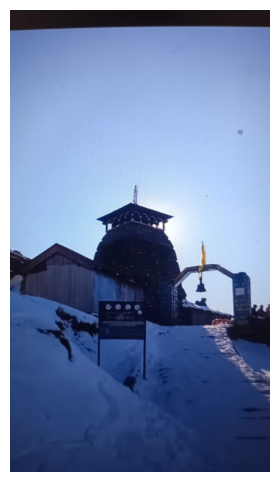

Predicted Class: real

Probabilities:
real: 0.6363
screen: 0.3637

Screen Score: 0.3637


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

img_path = "screen1.jpeg"

image = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = val_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)

    pred = torch.argmax(probabilities, dim=1).item()

# Class names
classes = full_dataset.classes

print(f"Predicted Class: {classes[pred]}")
print("\nProbabilities:")

for i, cls in enumerate(classes):
    print(f"{cls}: {probabilities[0][i].item():.4f}")

# Assignment score (0 = real, 1 = screen)
screen_idx = classes.index('screen')
screen_score = probabilities[0][screen_idx].item()

print(f"\nScreen Score: {screen_score:.4f}")